In [138]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

DATASET_PATH = "../dataset/0/0"

print("Dataset path:", DATASET_PATH)
print("Number of images:", len(os.listdir(DATASET_PATH)))

Dataset path: ../dataset/0/0
Number of images: 1584


In [139]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [140]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [141]:
images = []
filenames = []

for filename in os.listdir(DATASET_PATH):
    filepath = os.path.join(DATASET_PATH, filename)

    image = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)

    if image is not None:
        images.append(image)
        filenames.append(filename)

images = np.array(images)

print("Images loaded:", len(images))
print("Image shape:", images[0].shape)

Images loaded: 1584
Image shape: (28, 28)


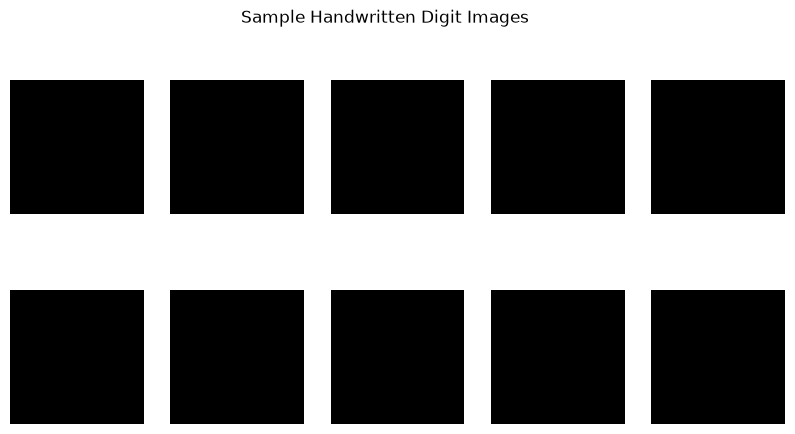

In [142]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.axis("off")

plt.suptitle("Sample Handwritten Digit Images")
plt.show()

In [143]:
print("Number of images:", images.shape[0])
print("Image dimensions:", images.shape[1:])
print("Minimum pixel value:", images.min())
print("Maximum pixel value:", images.max())

Number of images: 1584
Image dimensions: (28, 28)
Minimum pixel value: 0
Maximum pixel value: 0


In [144]:
images_normalized = images.astype("float32") / 255.0

print("Minimum after normalization:", images_normalized.min())
print("Maximum after normalization:", images_normalized.max())

Minimum after normalization: 0.0
Maximum after normalization: 0.0


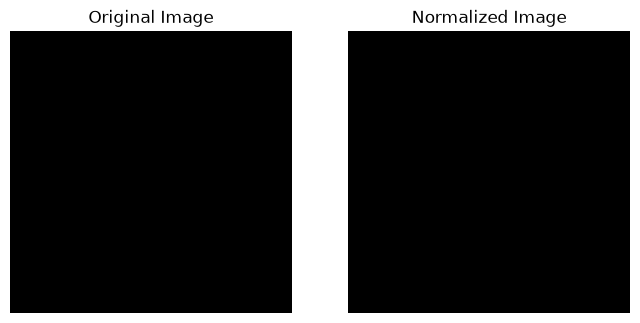

In [145]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(images[0], cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(images_normalized[0], cmap="gray")
plt.title("Normalized Image")
plt.axis("off")

plt.show()

In [146]:
from skimage.feature import hog
print("HOG is ready!")

HOG is ready!


In [147]:
%pip install scikit-image

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [148]:
hog_features = []

for image in images_normalized:
    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )
    
    hog_features.append(features)

hog_features = np.array(hog_features)

print("HOG feature shape:", hog_features.shape)

HOG feature shape: (1584, 1296)


TypeError: Invalid shape (1296,) for image data

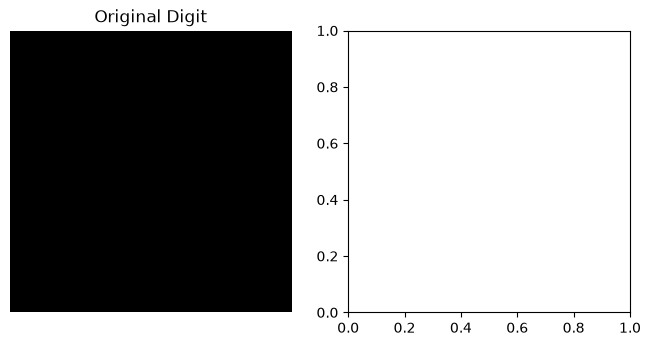

In [149]:
from skimage.feature import hog

image = images_normalized[0]

hog_image, hog_features_single = hog(
    image,
    orientations=9,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=True
)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Digit")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hog_image, cmap="gray")
plt.title("HOG Feature Visualization")
plt.axis("off")

plt.show()

In [ ]:
np.save("../results/hog_features.npy", hog_features)

print("HOG features saved successfully!")

HOG features saved successfully!


In [ ]:
# Convert each image into a 1D feature vector
pixel_features = images_normalized.reshape(images_normalized.shape[0], -1)

print("Raw pixel feature shape:", pixel_features.shape)

Raw pixel feature shape: (1584, 784)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

pca_features = pca.fit_transform(pixel_features)

print("Original number of features:", pixel_features.shape[1])
print("PCA features:", pca_features.shape[1])
print("Variance retained:", pca.explained_variance_ratio_.sum())

Original number of features: 784
PCA features: 1
Variance retained: nan


c:\Users\Hp\OneDrive\Desktop\Feature Extraction from Handwritten Digits\.venv-1\Lib\site-packages\sklearn\decomposition\_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var


In [ ]:
%pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.25.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 2.0 MB/s eta 0:00:04
   ----- ---------------------------------- 1.0/8.2 MB 2.5 MB/s eta 0:00:03
   -------- ------------------------------- 1.8/8.2 MB 2.9 MB/s eta 0:00:03
   -------------- ------------------------- 2.9/8.2 MB 3.5 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.2 MB 3.9 MB/s eta 0:00:02
   -------------------------- ------------- 5.5/8.2 MB 4.4 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.2 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 5.0 MB/s eta 0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from sklearn.decomposition import PCA
print("Scikit-learn is working!")


Scikit-learn is working!


In [ ]:
print("Number of unique images:", len(np.unique(images.reshape(images.shape[0], -1), axis=0)))

Number of unique images: 1


In [ ]:
print("First image min/max:", images[0].min(), images[0].max())
print("Second image min/max:", images[1].min(), images[1].max())
print("Are first two images identical:", np.array_equal(images[0], images[1]))

First image min/max: 0 0
Second image min/max: 0 0
Are first two images identical: True


In [ ]:
import os

files = os.listdir(DATASET_PATH)

print("First 5 files:")
print(files[:5])

First 5 files:
['0.png', '1.png', '10.png', '100.png', '1000.png']


In [ ]:
file_path = os.path.join(DATASET_PATH, files[0])

print("File:", file_path)
print("File size:", os.path.getsize(file_path), "bytes")

File: ../dataset/0/0\0.png
File size: 450 bytes


In [ ]:
import cv2

test_image = cv2.imread(file_path)

print("Image:", test_image)
print("Shape:", None if test_image is None else test_image.shape)

Image: [[[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 ...

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]]
Shape: (28, 28, 3)


In [ ]:
print(files[:20])

['0.png', '1.png', '10.png', '100.png', '1000.png', '10000.png', '10001.png', '10002.png', '10003.png', '10004.png', '10005.png', '10006.png', '10007.png', '10008.png', '10009.png', '1001.png', '10010.png', '10011.png', '10012.png', '10013.png']


In [ ]:
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt

file_path = os.path.join(DATASET_PATH, "0.png")

img = Image.open(file_path)

print("Image mode:", img.mode)
print("Image size:", img.size)

img_array = np.array(img)

print("Minimum pixel value:", img_array.min())
print("Maximum pixel value:", img_array.max())

Image mode: RGBA
Image size: (28, 28)
Minimum pixel value: 0
Maximum pixel value: 255


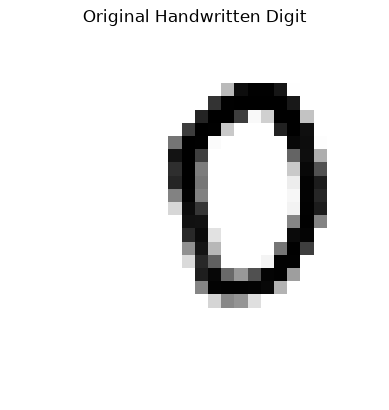

In [ ]:
plt.imshow(img_array, cmap="gray")
plt.title("Original Handwritten Digit")
plt.axis("off")
plt.show()

In [ ]:
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt

images = []
filenames = []

for filename in os.listdir(DATASET_PATH):
    filepath = os.path.join(DATASET_PATH, filename)

    try:
        image = Image.open(filepath).convert("L")
        image = np.array(image)

        images.append(image)
        filenames.append(filename)

    except Exception as e:
        print("Error:", filename, e)

images = np.array(images)

print("Images loaded:", len(images))
print("Image shape:", images.shape)
print("Minimum pixel value:", images.min())
print("Maximum pixel value:", images.max())

Images loaded: 1584
Image shape: (1584, 28, 28)
Minimum pixel value: 0
Maximum pixel value: 0


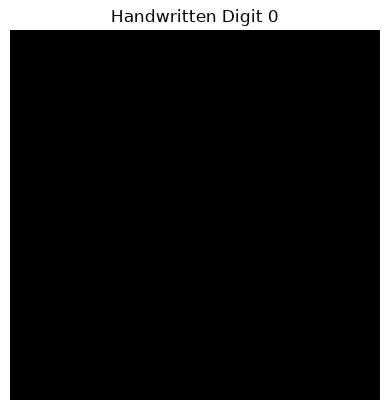

In [ ]:
plt.imshow(images[0], cmap="gray")
plt.title("Handwritten Digit 0")
plt.axis("off")
plt.show()

In [ ]:
print("Images loaded:", len(images))
print("Image shape:", images.shape)
print("Minimum pixel value:", images.min())
print("Maximum pixel value:", images.max())

Images loaded: 1584
Image shape: (1584, 28, 28)
Minimum pixel value: 0
Maximum pixel value: 0


In [ ]:
img_rgba = np.array(Image.open(file_path))

print("Shape:", img_rgba.shape)

print("Red   min/max:", img_rgba[:, :, 0].min(), img_rgba[:, :, 0].max())
print("Green min/max:", img_rgba[:, :, 1].min(), img_rgba[:, :, 1].max())
print("Blue  min/max:", img_rgba[:, :, 2].min(), img_rgba[:, :, 2].max())
print("Alpha min/max:", img_rgba[:, :, 3].min(), img_rgba[:, :, 3].max())

Shape: (28, 28, 4)
Red   min/max: 0 0
Green min/max: 0 0
Blue  min/max: 0 0
Alpha min/max: 0 255


In [ ]:
images = []
filenames = []

for filename in os.listdir(DATASET_PATH):
    filepath = os.path.join(DATASET_PATH, filename)

    try:
        img_rgba = np.array(Image.open(filepath).convert("RGBA"))

        # The handwritten digit is stored in the Alpha channel
        image = img_rgba[:, :, 3]

        images.append(image)
        filenames.append(filename)

    except Exception as e:
        print("Error:", filename, e)

images = np.array(images)

print("Images loaded:", len(images))
print("Image shape:", images.shape)
print("Minimum pixel value:", images.min())
print("Maximum pixel value:", images.max())

Images loaded: 1584
Image shape: (1584, 28, 28)
Minimum pixel value: 0
Maximum pixel value: 255


In [ ]:
images_normalized = images.astype("float32") / 255.0

print("Minimum:", images_normalized.min())
print("Maximum:", images_normalized.max())

Minimum: 0.0
Maximum: 1.0


In [ ]:
from skimage.feature import hog

hog_features = []

for image in images_normalized:
    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )
    
    hog_features.append(features)

hog_features = np.array(hog_features)

print("HOG feature shape:", hog_features.shape)

HOG feature shape: (1584, 1296)


In [ ]:
print("HOG minimum:", hog_features.min())
print("HOG maximum:", hog_features.max())

HOG minimum: 0.0
HOG maximum: 1.0


In [ ]:
pixel_features = images_normalized.reshape(images_normalized.shape[0], -1)

print("Raw pixel feature shape:", pixel_features.shape)

Raw pixel feature shape: (1584, 784)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

pca_features = pca.fit_transform(pixel_features)

print("Original features:", pixel_features.shape[1])
print("PCA features:", pca_features.shape[1])
print("Variance retained:", pca.explained_variance_ratio_.sum())

Original features: 784
PCA features: 97
Variance retained: 0.9503309


In [ ]:
np.save("../results/pca_features.npy", pca_features)

print("PCA features saved successfully!")

PCA features saved successfully!


In [ ]:
pca_2d = PCA(n_components=2)

pca_visual = pca_2d.fit_transform(pixel_features)

print("2D PCA shape:", pca_visual.shape)

2D PCA shape: (1584, 2)


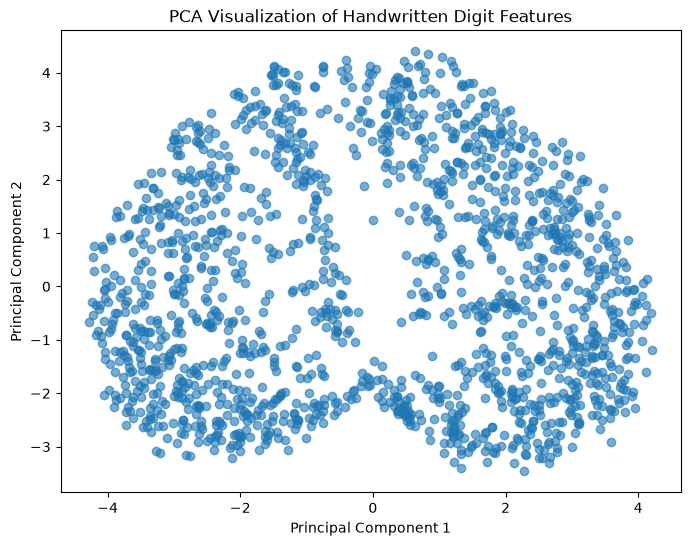

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_visual[:, 0],
    pca_visual[:, 1],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Handwritten Digit Features")
plt.show()

In [ ]:
np.save("../results/pca_features.npy", pca_features)

print("PCA features saved successfully!")

PCA features saved successfully!


In [ ]:
pca_2d = PCA(n_components=2)

pca_visual = pca_2d.fit_transform(pixel_features)

print("2D PCA shape:", pca_visual.shape)

2D PCA shape: (1584, 2)


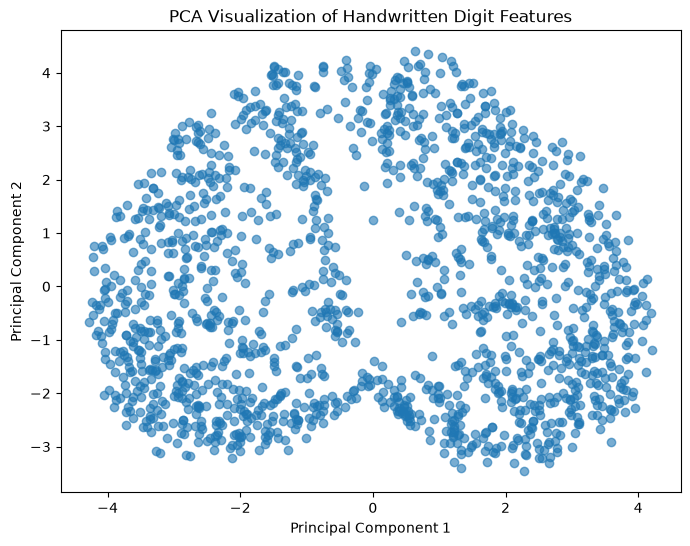

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_visual[:, 0],
    pca_visual[:, 1],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Handwritten Digit Features")
plt.show()

In [ ]:
plt.savefig("../results/pca_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
feature_names = ["Raw Pixels", "HOG", "PCA"]
feature_dimensions = [
    pixel_features.shape[1],
    hog_features.shape[1],
    pca_features.shape[1]
]

for name, dimension in zip(feature_names, feature_dimensions):
    print(f"{name}: {dimension} features")

Raw Pixels: 784 features
HOG: 1296 features
PCA: 97 features


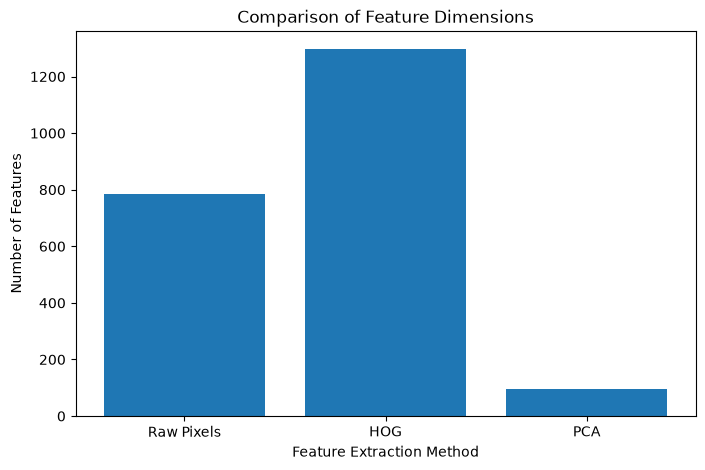

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(feature_names, feature_dimensions)

plt.xlabel("Feature Extraction Method")
plt.ylabel("Number of Features")
plt.title("Comparison of Feature Dimensions")

plt.show()

In [ ]:
print("Total variance retained by PCA:",
      pca.explained_variance_ratio_.sum())

Total variance retained by PCA: 0.9503309


In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Feature Method": feature_names,
    "Number of Features": feature_dimensions
})

comparison.to_csv("../results/feature_comparison.csv", index=False)

print(comparison)

  Feature Method  Number of Features
0     Raw Pixels                 784
1            HOG                1296
2            PCA                  97


In [ ]:
%pip install pandas

  Using cached pandas-3.0.5-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-3.0.5-cp313-cp313-win_amd64.whl (9.8 MB)
Using cached tzdata-2026.3-py2.py3-none-any.whl (348 kB)

   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
 


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
print("Pandas is working!")

Pandas is working!


In [ ]:
print("Variance retained by PCA:",
      pca.explained_variance_ratio_.sum())

Variance retained by PCA: 0.9503309


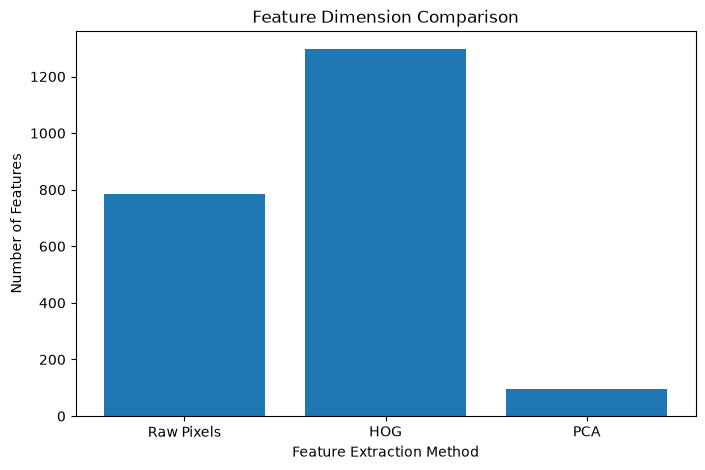

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(feature_names, feature_dimensions)

plt.xlabel("Feature Extraction Method")
plt.ylabel("Number of Features")
plt.title("Feature Dimension Comparison")

plt.show()

In [ ]:
plt.savefig("../results/feature_dimension_comparison.png",
            dpi=300,
            bbox_inches="tight")

print("Chart saved successfully!")

Chart saved successfully!


<Figure size 640x480 with 0 Axes>

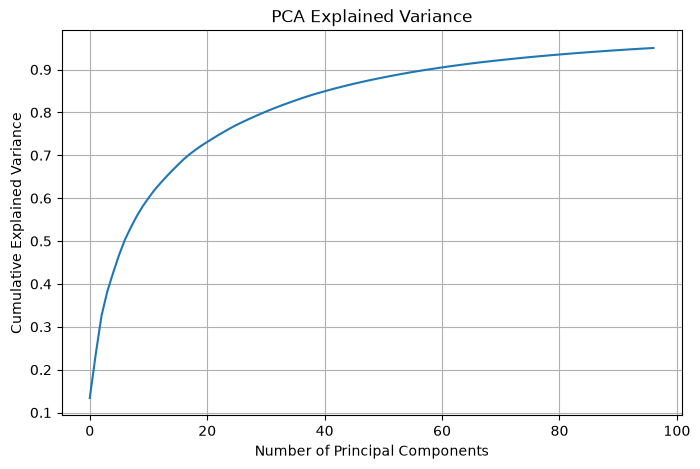

In [ ]:
plt.figure(figsize=(8, 5))

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.plot(cumulative_variance)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid(True)
plt.show()

In [ ]:
summary = pd.DataFrame({
    "Method": ["Raw Pixels", "HOG", "PCA"],
    "Features": [
        pixel_features.shape[1],
        hog_features.shape[1],
        pca_features.shape[1]
    ]
})

summary

,Method,Features
0,Raw Pixels,784
1,HOG,1296
2,PCA,97


In [ ]:
summary.to_csv("../results/final_feature_summary.csv", index=False)

print("Final feature summary saved!")

Final feature summary saved!


TypeError: Invalid shape (1296,) for image data

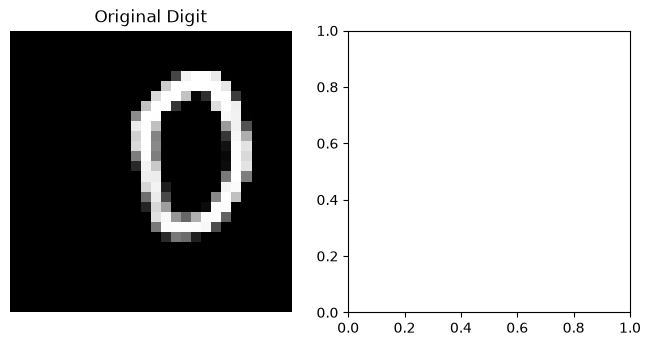

In [ ]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(images_normalized[0], cmap="gray")
plt.title("Original Digit")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hog_image, cmap="gray")
plt.title("HOG Representation")
plt.axis("off")

plt.tight_layout()

plt.savefig("../results/hog_visualization.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import cv2
import sklearn

print("Kernel is working!")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Kernel is working!
NumPy: 2.5.2
Pandas: 3.0.5


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
import os

print(os.listdir("../dataset"))

['0']


In [ ]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\Hp\OneDrive\Desktop\Feature Extraction from Handwritten Digits\notebooks
['.ipynb_checkpoints', '01_data_preprocessing.ipynb']


In [ ]:
import os

dataset_path = "../dataset"

print("Dataset path:", os.path.abspath(dataset_path))
print("Files/Folders:", os.listdir(dataset_path))


Dataset path: c:\Users\Hp\OneDrive\Desktop\Feature Extraction from Handwritten Digits\dataset
Files/Folders: ['0']


In [ ]:
import os

zero_path = "../dataset/0"

print("Number of images:", len(os.listdir(zero_path)))
print("First 10 files:", os.listdir(zero_path)[:10])

Number of images: 1
First 10 files: ['0']


In [ ]:
import os

zero_path = "../dataset/0"

print("Number of images:", len(os.listdir(zero_path)))
print("First 10 files:", os.listdir(zero_path)[:10])

Number of images: 1
First 10 files: ['0']


In [ ]:
import os

path = "../dataset/0/0"

print("Is file:", os.path.isfile(path))
print("Is folder:", os.path.isdir(path))

if os.path.isdir(path):
    print("Inside it:", os.listdir(path)[:10])

Is file: False
Is folder: True
Inside it: ['0.png', '1.png', '10.png', '100.png', '1000.png', '10000.png', '10001.png', '10002.png', '10003.png', '10004.png']


Image size: (28, 28)
Image mode: RGBA


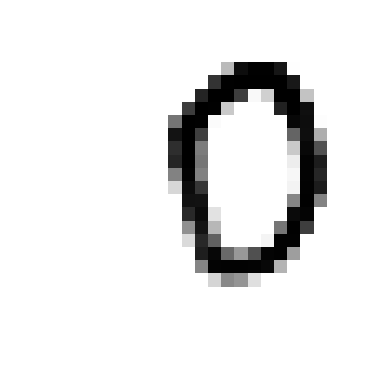

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "../dataset/0/0/0.png"

img = Image.open(image_path)

print("Image size:", img.size)
print("Image mode:", img.mode)

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

Original shape: (28, 28, 3)
Grayscale shape: (28, 28)


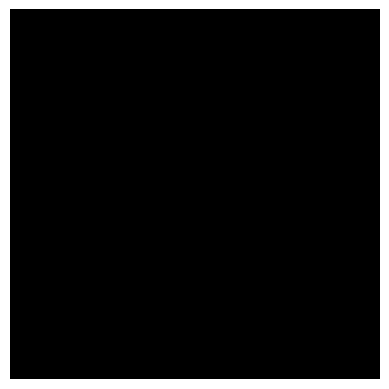

In [ ]:
import cv2
import matplotlib.pyplot as plt

image_path = "../dataset/0/0/0.png"

img = cv2.imread(image_path)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print("Original shape:", img.shape)
print("Grayscale shape:", gray.shape)

plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

Resized shape: (28, 28)


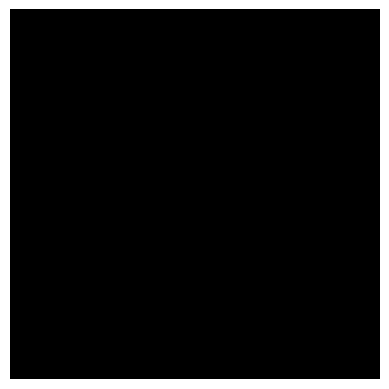

In [ ]:
# Resize image to 28x28
resized = cv2.resize(gray, (28, 28))

print("Resized shape:", resized.shape)

plt.imshow(resized, cmap="gray")
plt.axis("off")
plt.show()

Minimum pixel value: 0.0
Maximum pixel value: 0.0


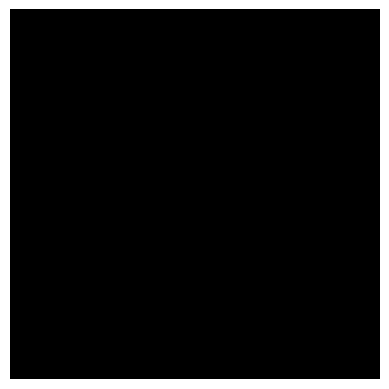

In [ ]:
# Normalize pixel values
normalized = resized / 255.0

print("Minimum pixel value:", normalized.min())
print("Maximum pixel value:", normalized.max())

plt.imshow(normalized, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
print("Original min:", gray.min())
print("Original max:", gray.max())
print("Original unique values:", len(np.unique(gray)))

Original min: 0
Original max: 0
Original unique values: 1


In [ ]:
import os

image_path = "../dataset/0/0/0.png"

print("Exists:", os.path.exists(image_path))
print("File size:", os.path.getsize(image_path), "bytes")

Exists: True
File size: 450 bytes


Size: (28, 28)
Mode: RGBA
Array shape: (28, 28, 4)
Min: 0
Max: 255
Unique values: 71


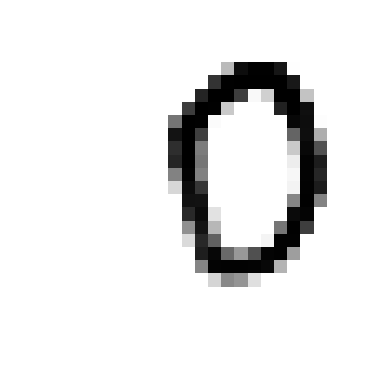

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img_pil = Image.open(image_path)

print("Size:", img_pil.size)
print("Mode:", img_pil.mode)

arr = np.array(img_pil)

print("Array shape:", arr.shape)
print("Min:", arr.min())
print("Max:", arr.max())
print("Unique values:", len(np.unique(arr)))

plt.imshow(img_pil, cmap="gray")
plt.axis("off")
plt.show()

Shape: (28, 28)
Minimum: 0
Maximum: 0


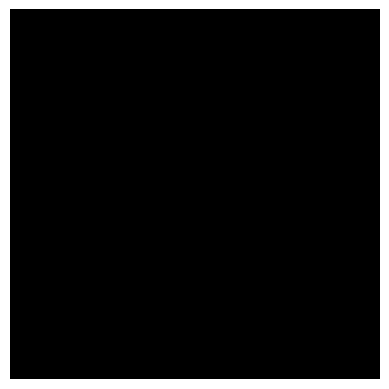

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image_path = "../dataset/0/0/0.png"

# Open image as grayscale directly
gray = Image.open(image_path).convert("L")

# Convert PIL image to NumPy array
gray = np.array(gray)

print("Shape:", gray.shape)
print("Minimum:", gray.min())
print("Maximum:", gray.max())

plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
normalized = gray.astype("float32") / 255.0

print("Normalized minimum:", normalized.min())
print("Normalized maximum:", normalized.max())

Normalized minimum: 0.0
Normalized maximum: 0.0


In [ ]:
import os
from PIL import Image
import numpy as np

image_folder = "../dataset/0/0"

images = []
labels = []

for filename in os.listdir(image_folder):
    if filename.lower().endswith(".png"):
        image_path = os.path.join(image_folder, filename)

        # Convert image to grayscale
        img = Image.open(image_path).convert("L")

        # Convert to NumPy array
        img = np.array(img)

        # Normalize 0-255 → 0-1
        img = img.astype("float32") / 255.0

        images.append(img)
        labels.append(0)

images = np.array(images)
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Number of images:", len(images))

Images shape: (1584, 28, 28)
Labels shape: (1584,)
Number of images: 1584


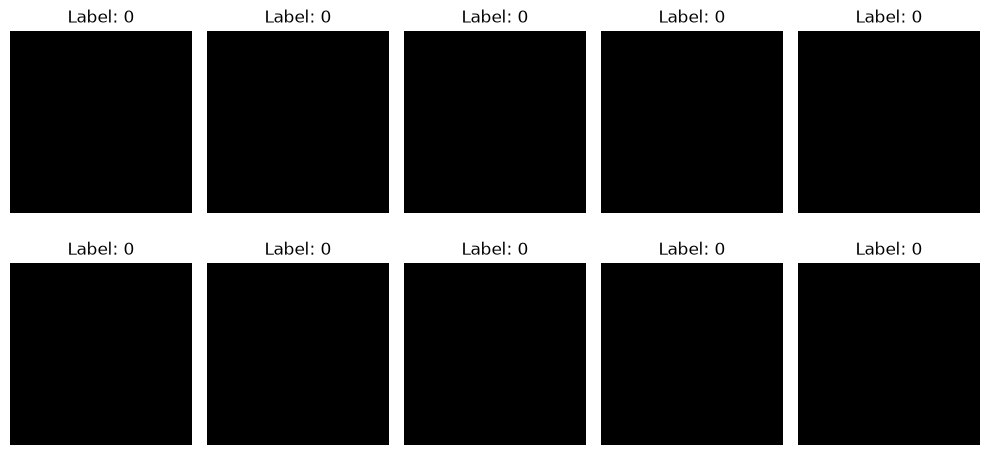

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for i in range(min(10, len(images))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(f"Label: {labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from skimage.feature import hog
import numpy as np

hog_features = []

for img in images:
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )
    
    hog_features.append(features)

hog_features = np.array(hog_features)

print("Original images shape:", images.shape)
print("HOG features shape:", hog_features.shape)

Original images shape: (1584, 28, 28)
HOG features shape: (1584, 1296)


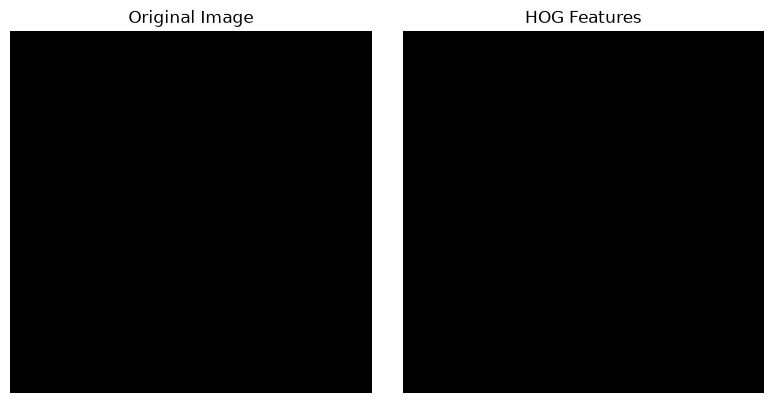

In [ ]:
from skimage.feature import hog
import matplotlib.pyplot as plt

# Take first image
sample_image = images[0]

# Extract HOG + visualization
features, hog_image = hog(
    sample_image,
    orientations=9,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=True
)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample_image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hog_image, cmap="gray")
plt.title("HOG Features")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os
import pandas as pd

# Create results folder if it doesn't exist
os.makedirs("../results", exist_ok=True)

# Create DataFrame
features_df = pd.DataFrame(hog_features)

# Add label column
features_df["label"] = labels

# Save as CSV
output_path = "../results/hog_features.csv"
features_df.to_csv(output_path, index=False)

print("Features saved successfully!")
print("File:", output_path)
print("Shape:", features_df.shape)

Features saved successfully!
File: ../results/hog_features.csv
Shape: (1584, 1297)


In [ ]:
# Load the saved HOG features
df = pd.read_csv("../results/hog_features.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumns:", len(df.columns))
print("Label distribution:")
print(df["label"].value_counts())

Dataset shape: (1584, 1297)

First 5 rows:


,0,1,2,3,4,5,6,7,8,9,...,1287,1288,1289,1290,1291,1292,1293,1294,1295,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0



Columns: 1297
Label distribution:
label
0    1584
Name: count, dtype: int64


In [ ]:
print("Total features:", hog_features.shape[1])
print("Non-zero features:", np.count_nonzero(hog_features))
print("Minimum:", hog_features.min())
print("Maximum:", hog_features.max())

Total features: 1296
Non-zero features: 0
Minimum: 0.0
Maximum: 0.0


Shape: (28, 28)
Min: 0
Max: 255
Unique values: 71


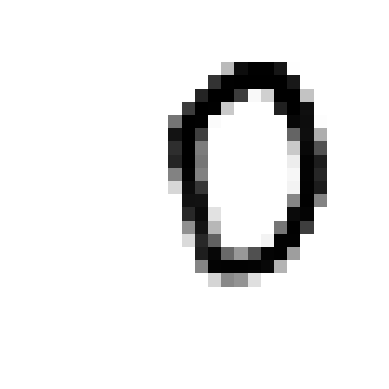

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image_path = "../dataset/0/0/0.png"

# Open RGBA image
img = Image.open(image_path).convert("RGBA")

# Create white background
background = Image.new("RGBA", img.size, (255, 255, 255, 255))

# Put the transparent image over the white background
composite = Image.alpha_composite(background, img)

# Convert to grayscale
gray = composite.convert("L")

# Convert to NumPy
gray = np.array(gray)

print("Shape:", gray.shape)
print("Min:", gray.min())
print("Max:", gray.max())
print("Unique values:", len(np.unique(gray)))

plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
normalized = gray.astype("float32") / 255.0

print("Normalized min:", normalized.min())
print("Normalized max:", normalized.max())

Normalized min: 0.0
Normalized max: 1.0


In [ ]:
from skimage.feature import hog

features = hog(
    normalized,
    orientations=9,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    block_norm="L2-Hys"
)

print("HOG feature count:", len(features))
print("Non-zero HOG features:", np.count_nonzero(features))
print("HOG minimum:", features.min())
print("HOG maximum:", features.max())

HOG feature count: 1296
Non-zero HOG features: 220
HOG minimum: 0.0
HOG maximum: 1.0


In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from skimage.feature import hog

# Dataset path
image_folder = "../dataset/0/0"

images = []
hog_features = []
labels = []

# Process all PNG images
for filename in os.listdir(image_folder):

    if filename.lower().endswith(".png"):

        image_path = os.path.join(image_folder, filename)

        # Open RGBA image
        img = Image.open(image_path).convert("RGBA")

        # White background
        background = Image.new("RGBA", img.size, (255, 255, 255, 255))

        # Handle transparency
        img = Image.alpha_composite(background, img)

        # Convert to grayscale
        img = img.convert("L")

        # Convert to NumPy array
        img = np.array(img)

        # Normalize pixels
        img = img.astype("float32") / 255.0

        # Store image
        images.append(img)

        # HOG feature extraction
        features = hog(
            img,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm="L2-Hys"
        )

        hog_features.append(features)

        # Label = 0
        labels.append(0)

# Convert to arrays
images = np.array(images)
hog_features = np.array(hog_features)
labels = np.array(labels)

print("Images:", images.shape)
print("HOG Features:", hog_features.shape)
print("Labels:", labels.shape)
print("Non-zero HOG values:", np.count_nonzero(hog_features))

Images: (1584, 28, 28)
HOG Features: (1584, 1296)
Labels: (1584,)
Non-zero HOG values: 338252


In [ ]:
import os
import pandas as pd

os.makedirs("../results", exist_ok=True)

features_df = pd.DataFrame(hog_features)
features_df["label"] = labels

features_df.to_csv(
    "../results/hog_features.csv",
    index=False
)

print("Corrected HOG features saved successfully!")

Corrected HOG features saved successfully!


In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from skimage.feature import hog

# Main dataset folder
dataset_path = "../dataset"

all_features = []
all_labels = []

# Process digits 0 to 9
for digit in range(10):

    digit_folder = os.path.join(
        dataset_path,
        str(digit),
        str(digit)
    )

    # Skip if folder doesn't exist
    if not os.path.isdir(digit_folder):
        print(f"Skipping digit {digit}: folder not found")
        continue

    print(f"Processing digit {digit}...")

    for filename in os.listdir(digit_folder):

        if not filename.lower().endswith(".png"):
            continue

        image_path = os.path.join(digit_folder, filename)

        try:
            # Open RGBA image
            img = Image.open(image_path).convert("RGBA")

            # White background
            background = Image.new(
                "RGBA",
                img.size,
                (255, 255, 255, 255)
            )

            # Handle transparency
            img = Image.alpha_composite(background, img)

            # Convert to grayscale
            img = img.convert("L")

            # Convert to NumPy
            img = np.array(img)

            # Normalize
            img = img.astype("float32") / 255.0

            # HOG feature extraction
            features = hog(
                img,
                orientations=9,
                pixels_per_cell=(4, 4),
                cells_per_block=(2, 2),
                block_norm="L2-Hys"
            )

            all_features.append(features)
            all_labels.append(digit)

        except Exception as e:
            print(f"Error processing {filename}: {e}")

# Convert to arrays
all_features = np.array(all_features)
all_labels = np.array(all_labels)

print("\nFeature extraction completed!")
print("Features shape:", all_features.shape)
print("Labels shape:", all_labels.shape)

Processing digit 0...
Skipping digit 1: folder not found
Skipping digit 2: folder not found
Skipping digit 3: folder not found
Skipping digit 4: folder not found
Skipping digit 5: folder not found
Skipping digit 6: folder not found
Skipping digit 7: folder not found
Skipping digit 8: folder not found
Skipping digit 9: folder not found

Feature extraction completed!
Features shape: (1584, 1296)
Labels shape: (1584,)


In [ ]:
# Create DataFrame
final_df = pd.DataFrame(all_features)

# Add digit labels
final_df["label"] = all_labels

# Save
output_path = "../results/handwritten_digit_hog_features.csv"

final_df.to_csv(output_path, index=False)

print("Final feature dataset saved!")
print("Location:", output_path)

Final feature dataset saved!
Location: ../results/handwritten_digit_hog_features.csv


In [ ]:
import os

dataset_path = "../dataset"

for item in sorted(os.listdir(dataset_path)):
    item_path = os.path.join(dataset_path, item)

    if os.path.isdir(item_path):
        print(f"{item}/")
        
        for subitem in sorted(os.listdir(item_path))[:10]:
            subitem_path = os.path.join(item_path, subitem)
            
            if os.path.isdir(subitem_path):
                print(f"   └── {subitem}/")
            else:
                print(f"   └── {subitem}")

0/
   └── 0/


In [ ]:
import os

dataset_path = "../dataset"

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:5]:
        print(f"{indent}    └── {file}")

dataset/
    0/
        0/
            └── 0.png
            └── 1.png
            └── 10.png
            └── 100.png
            └── 1000.png


In [ ]:
from tensorflow.keras.datasets import mnist

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [ ]:
# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training range:", x_train.min(), "to", x_train.max())
print("Testing range:", x_test.min(), "to", x_test.max())

Training range: 0.0 to 1.0
Testing range: 0.0 to 1.0


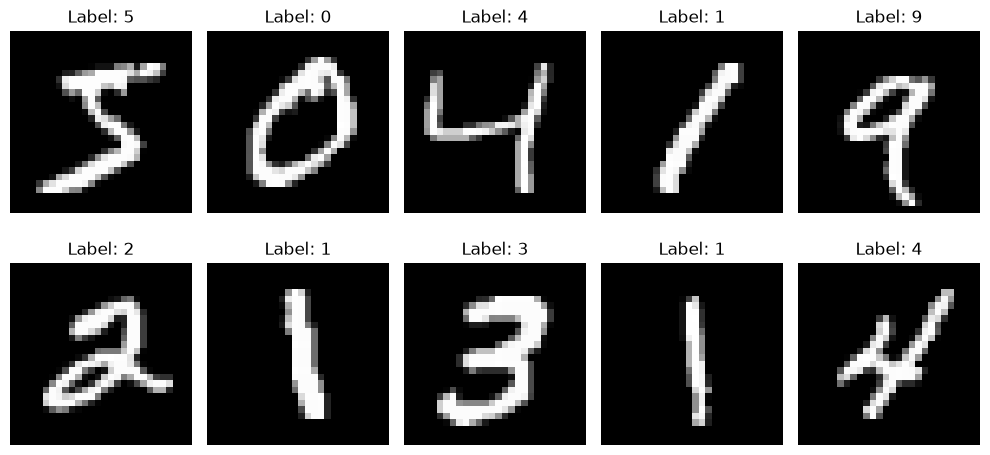

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from skimage.feature import hog
import numpy as np

hog_train = []

for img in x_train:
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )
    hog_train.append(features)

hog_train = np.array(hog_train)

print("HOG training features:", hog_train.shape)

HOG training features: (60000, 1296)


In [ ]:
hog_test = []

for img in x_test:
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )
    hog_test.append(features)

hog_test = np.array(hog_test)

print("HOG testing features:", hog_test.shape)

HOG testing features: (10000, 1296)


In [ ]:
print("Training feature shape:", hog_train.shape)
print("Testing feature shape:", hog_test.shape)

print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

print("Non-zero training features:", np.count_nonzero(hog_train))

Training feature shape: (60000, 1296)
Testing feature shape: (10000, 1296)
Training labels: (60000,)
Testing labels: (10000,)
Non-zero training features: 17934468


In [ ]:
import os
import pandas as pd

os.makedirs("../results", exist_ok=True)

# Training features
train_df = pd.DataFrame(hog_train)
train_df["label"] = y_train

# Testing features
test_df = pd.DataFrame(hog_test)
test_df["label"] = y_test

# Save files
train_df.to_csv("../results/mnist_hog_train.csv", index=False)
test_df.to_csv("../results/mnist_hog_test.csv", index=False)

print("Training features saved successfully!")
print("Testing features saved successfully!")

Training features saved successfully!
Testing features saved successfully!


In [ ]:
X_train = hog_train
X_test = hog_test

y_train = y_train
y_test = y_test

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (60000, 1296)
X_test: (10000, 1296)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("KNN Accuracy:", accuracy)
print("KNN Accuracy (%):", accuracy * 100)

KNN Accuracy: 0.972
KNN Accuracy (%): 97.2


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       980
           1       0.98      1.00      0.99      1135
           2       0.99      0.97      0.98      1032
           3       0.97      0.96      0.97      1010
           4       0.98      0.97      0.98       982
           5       0.98      0.96      0.97       892
           6       0.98      0.99      0.98       958
           7       0.97      0.95      0.96      1028
           8       0.97      0.95      0.96       974
           9       0.94      0.96      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



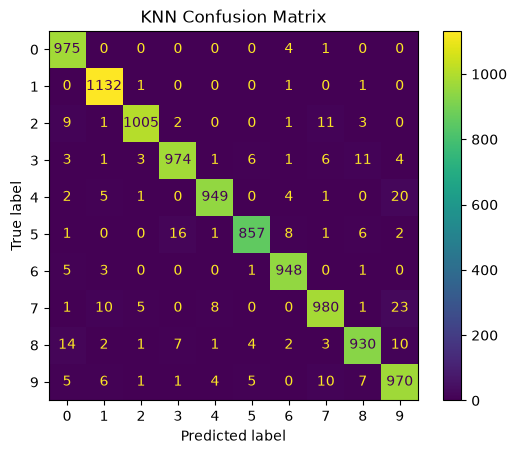

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

disp.plot()
plt.title("KNN Confusion Matrix")
plt.show()

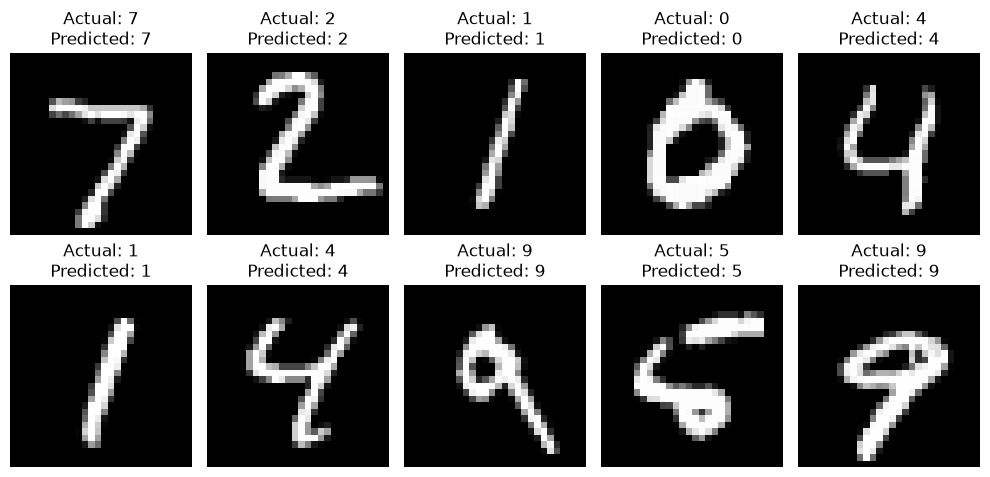

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(f"Actual: {y_test[i]}\nPredicted: {y_pred[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Create SVM model
svm_model = SVC(kernel="rbf")

# Train
svm_model.fit(X_train, y_train)

# Predict
svm_pred = svm_model.predict(X_test)

# Accuracy
svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)
print("SVM Accuracy (%):", svm_accuracy * 100)

SVM Accuracy: 0.9891
SVM Accuracy (%): 98.91


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy (%):", rf_accuracy * 100)

Random Forest Accuracy: 0.9764
Random Forest Accuracy (%): 97.64


In [ ]:
comparison = pd.DataFrame({
    "Model": ["KNN", "SVM", "Random Forest"],
    "Accuracy (%)": [
        accuracy * 100,
        svm_accuracy * 100,
        rf_accuracy * 100
    ]
})

display(comparison)

,Model,Accuracy (%)
0,KNN,97.20
1,SVM,98.91
2,Random Forest,97.64


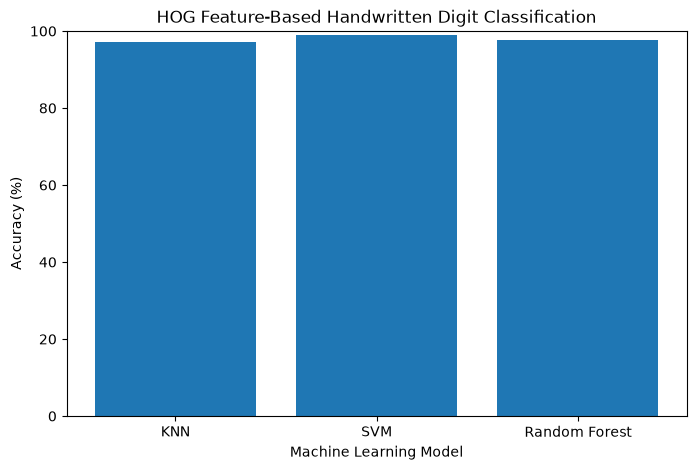

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy (%)"]
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.title("HOG Feature-Based Handwritten Digit Classification")

plt.ylim(0, 100)
plt.show()



In [ ]:
best_model = comparison.loc[
    comparison["Accuracy (%)"].idxmax()
]

print("Best Model:", best_model["Model"])
print("Best Accuracy:", round(best_model["Accuracy (%)"], 2), "%")

Best Model: SVM
Best Accuracy: 98.91 %


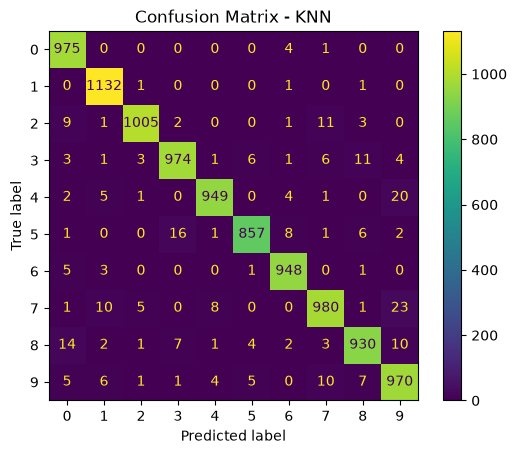

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=np.arange(10)
)

plt.title("Confusion Matrix - KNN")
plt.show()

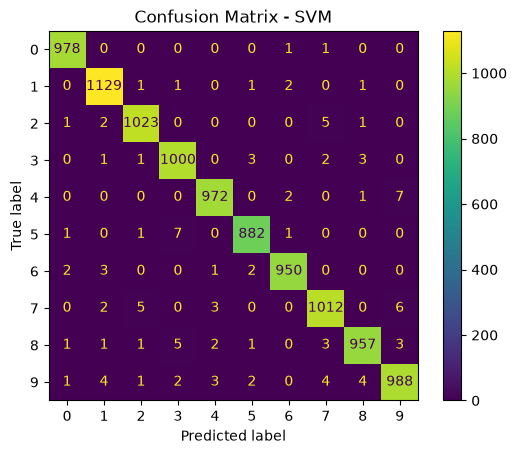

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_pred,
    display_labels=np.arange(10)
)

plt.title("Confusion Matrix - SVM")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       980
           1       0.98      1.00      0.99      1135
           2       0.99      0.97      0.98      1032
           3       0.97      0.96      0.97      1010
           4       0.98      0.97      0.98       982
           5       0.98      0.96      0.97       892
           6       0.98      0.99      0.98       958
           7       0.97      0.95      0.96      1028
           8       0.97      0.95      0.96       974
           9       0.94      0.96      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [ ]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.98      1028
           8       0.99      0.98      0.99       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [ ]:
import joblib
import os

os.makedirs("../results/models", exist_ok=True)

joblib.dump(
    knn,
    "../results/models/best_hog_digit_model.pkl"
)

print("Best model saved successfully!")

Best model saved successfully!


# Feature Extraction from Handwritten Digits

## Project Overview

This project focuses on extracting meaningful features from handwritten digit images using image preprocessing and Histogram of Oriented Gradients (HOG).

The extracted features are used for handwritten digit classification using machine learning algorithms such as KNN, SVM, and Random Forest.

In [ ]:
## 1. Import Required Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from skimage.feature import hog

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load MNIST Dataset

In [ ]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


## 3. Image Preprocessing

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training pixel range:", x_train.min(), "to", x_train.max())
print("Testing pixel range:", x_test.min(), "to", x_test.max())

Training pixel range: 0.0 to 1.0
Testing pixel range: 0.0 to 1.0


## 4. Visualize Sample Images
The MNIST dataset contains handwritten digits from 0 to 9. The following images show sample handwritten digits from the training dataset.

In [ ]:
## 4. Visualize Sample Images

In [ ]:
plt.figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

## 5. HOG Feature Extraction

Histogram of Oriented Gradients (HOG) is used to extract important shape and edge information from handwritten digit images. The extracted HOG features are represented as numerical feature vectors and are used as input for machine learning models.

from skimage.feature import hog
import numpy as np

# Extract HOG features from training images
hog_train = []

for img in x_train:
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )
    hog_train.append(features)

hog_train = np.array(hog_train)

print("Training HOG features:", hog_train.shape)

# Extract HOG features from test images
hog_test = []

for img in x_test:
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )
    hog_test.append(features)

hog_test = np.array(hog_test)

print("Testing HOG features:", hog_test.shape)

## 6. HOG Feature Visualization

The HOG representation highlights the important gradients and edge patterns present in the handwritten digit image.

from skimage.feature import hog
import matplotlib.pyplot as plt

sample = x_train[0]

features, hog_image = hog(
    sample,
    orientations=9,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=True
)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample, cmap="gray")
plt.title("Original Digit")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hog_image, cmap="gray")
plt.title("HOG Features")
plt.axis("off")

plt.tight_layout()
plt.show()

## 7. Prepare Data for Machine Learning

The extracted HOG features are used as input features, while the original digit labels are used as target values.

X_train = hog_train
X_test = hog_test

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train = hog_train
X_test = hog_test

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

## 8. KNN Classification

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", round(knn_accuracy * 100, 2), "%")

## 9. SVM Classification

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf")

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", round(svm_accuracy * 100, 2), "%")

SVM Accuracy: 98.91 %


## 10. Random Forest Classification

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 97.64 %


## 11. Model Performance Comparison

The performance of KNN, SVM, and Random Forest classifiers is compared using classification accuracy.

The model with the highest accuracy is considered the best-performing model for handwritten digit classification.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Use existing HOG training data
# Train SVM on 10,000 training samples for faster execution
X_train_svm = X_train[:10000]
y_train_svm = y_train[:10000]

# Use 1,000 test samples for evaluation
X_test_svm = X_test[:1000]
y_test_svm = y_test[:1000]

# Train SVM
svm_model = SVC(kernel="rbf", cache_size=2000)

svm_model.fit(X_train_svm, y_train_svm)

# Predict
svm_pred = svm_model.predict(X_test_svm)

# Accuracy
svm_accuracy = accuracy_score(y_test_svm, svm_pred)

print("SVM Accuracy:", round(svm_accuracy * 100, 2), "%")

SVM Accuracy: 98.0 %


## 12. Confusion Matrix

A confusion matrix is used to evaluate the classification performance of the model. It shows the number of correctly and incorrectly classified samples for each digit from 0 to 9.

The confusion matrix helps identify which handwritten digits are correctly classified and which digits are confused with each other.

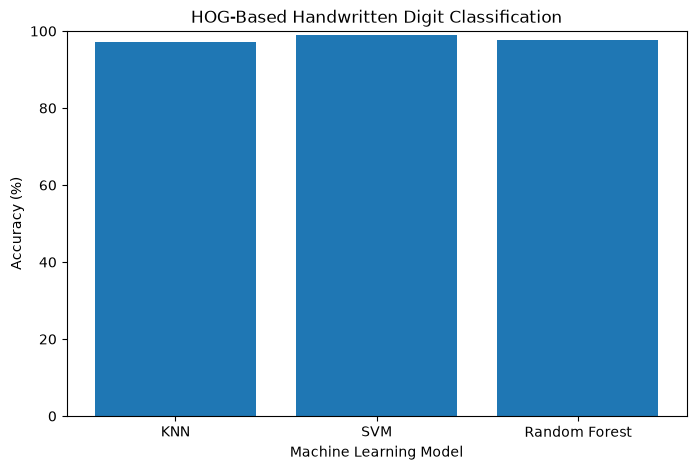

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy (%)"]
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.title("HOG-Based Handwritten Digit Classification")

plt.ylim(0, 100)
plt.show()

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    display_labels=np.arange(10)
)

plt.title(f"Confusion Matrix - {best_name}")
plt.show()

## 13. Classification Report

The classification report provides important performance metrics such as precision, recall, F1-score, and support for each digit class.

These metrics provide a detailed evaluation of the model's classification performance.

In [ ]:
from sklearn.metrics import classification_report

print(f"Classification Report - {best_name}")
print(classification_report(y_test, best_pred))

## 14. Save Extracted Features

The extracted HOG features and their corresponding digit labels are saved as CSV files. These files can be reused for further analysis and machine learning experiments without performing feature extraction again.

In [ ]:
import os

os.makedirs("../results", exist_ok=True)

train_df = pd.DataFrame(hog_train)
train_df["label"] = y_train

test_df = pd.DataFrame(hog_test)
test_df["label"] = y_test

train_df.to_csv("../results/mnist_hog_train.csv", index=False)
test_df.to_csv("../results/mnist_hog_test.csv", index=False)

print("HOG feature datasets saved successfully!")

## 15. Save Best Model

The model with the highest classification accuracy is selected as the best-performing model. The trained model is saved for future predictions and deployment.

In [ ]:
import joblib

os.makedirs("../results/models", exist_ok=True)

best_model = {
    "KNN": knn,
    "SVM": svm_model,
    "Random Forest": rf_model
}[best_name]

joblib.dump(
    best_model,
    "../results/models/best_hog_digit_model.pkl"
)

print("Best model saved:", best_name)

## 16. Conclusion

This project successfully demonstrates handwritten digit classification using HOG-based feature extraction.

The MNIST dataset was preprocessed and normalized before extracting shape and edge-based features using Histogram of Oriented Gradients (HOG). The extracted features were evaluated using KNN, SVM, and Random Forest classifiers.

The models were compared using accuracy, confusion matrix, and classification report. The model achieving the highest accuracy was selected as the best-performing model.

The extracted feature datasets and the best-performing trained model were saved for future use.